# Ground Truth Label Visualization

Compare 2D heatmap vs sparse point set representations of contact data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
import mujoco

from planner.experiments.data_capture import ContactProjector

DATASET_DIR = Path("datasets/v6")
SCENE_XML = "franka_emika_panda/scene_level2.xml"

In [2]:
# Load sample and pick a failure mode
SAMPLE_IDX = 0
import pandas as pd
manifest = pd.read_csv(DATASET_DIR / "manifest.csv")
sample = np.load(DATASET_DIR / manifest.iloc[SAMPLE_IDX]["npz_file"], allow_pickle=True)

failure_modes = sample["failure_modes"]
print("Failure modes:", list(failure_modes))
print("Pick one to visualize:")
for i, m in enumerate(failure_modes):
    n = (sample["contact_failure_id"] == i).sum()
    print(f"  [{i}] {m}: {n:,} contacts")

Failure modes: [np.str_('gripper_open'), np.str_('slippery_grip'), np.str_('single_joint'), np.str_('single_joint'), np.str_('multi_joint'), np.str_('all_joints')]
Pick one to visualize:
  [0] gripper_open: 8,937 contacts
  [1] slippery_grip: 8,908 contacts
  [2] single_joint: 16,725 contacts
  [3] single_joint: 8,023 contacts
  [4] multi_joint: 14,796 contacts
  [5] all_joints: 16,495 contacts


In [3]:
FAILURE_ID = 5  # all_joints (most complex)

mask = sample["contact_failure_id"] == FAILURE_ID
positions = sample["contact_positions"][mask]
forces = sample["contact_forces"][mask]
force_mag = np.linalg.norm(forces[:, :3], axis=1)

print(f"Mode: {failure_modes[FAILURE_ID]}")
print(f"Raw contacts: {len(positions):,}")
print(f"Force range: [{force_mag.min():.1f}, {force_mag.max():.1f}] N")

Mode: all_joints
Raw contacts: 16,495
Force range: [1.0, 414.7] N


## 1. 2D Contact Heatmap

Project 3D contacts onto the overhead camera view. Each pixel stores contact probability and peak force.

In [4]:
# Build projector matching data capture camera
model = mujoco.MjModel.from_xml_path(SCENE_XML)
projector = ContactProjector(model,
                             camera_lookat=[0.0, -0.35, 0.4],
                             camera_distance=1.1,
                             camera_azimuth=150,
                             camera_elevation=-65)

# Project all contacts to pixel coords
pixels, depths = projector.project(positions)
in_frame = projector.in_frame(pixels, depths)

px = pixels[in_frame]
fm = force_mag[in_frame]
fv = forces[in_frame, :3]
pos_v = positions[in_frame]

# Quarter-resolution heatmap (120 x 160)
H_MAP, W_MAP = 120, 160
SCALE = 4  # full res / heatmap res

heatmap_count = np.zeros((H_MAP, W_MAP), dtype=np.float32)
heatmap_peak_force = np.zeros((H_MAP, W_MAP), dtype=np.float32)
heatmap_mean_force = np.zeros((H_MAP, W_MAP), dtype=np.float32)
heatmap_force_vec = np.zeros((H_MAP, W_MAP, 3), dtype=np.float32)
heatmap_mean_z = np.zeros((H_MAP, W_MAP), dtype=np.float32)

for i in range(len(px)):
    u = int(np.clip(px[i, 0] / SCALE, 0, W_MAP - 1))
    v = int(np.clip(px[i, 1] / SCALE, 0, H_MAP - 1))
    heatmap_count[v, u] += 1
    heatmap_peak_force[v, u] = max(heatmap_peak_force[v, u], fm[i])
    heatmap_mean_force[v, u] += fm[i]
    heatmap_force_vec[v, u] += fv[i]
    heatmap_mean_z[v, u] += pos_v[i, 2]

# Normalize accumulators
active = heatmap_count > 0
heatmap_mean_force[active] /= heatmap_count[active]
heatmap_mean_z[active] /= heatmap_count[active]
heatmap_prob = (heatmap_count > 0).astype(np.float32)

print(f"Contacts in frame: {len(px):,}")
print(f"Active pixels: {active.sum()} / {H_MAP * W_MAP}")
print(f"Peak force in heatmap: {heatmap_peak_force.max():.1f} N")

Contacts in frame: 16,495
Active pixels: 109 / 19200
Peak force in heatmap: 414.7 N


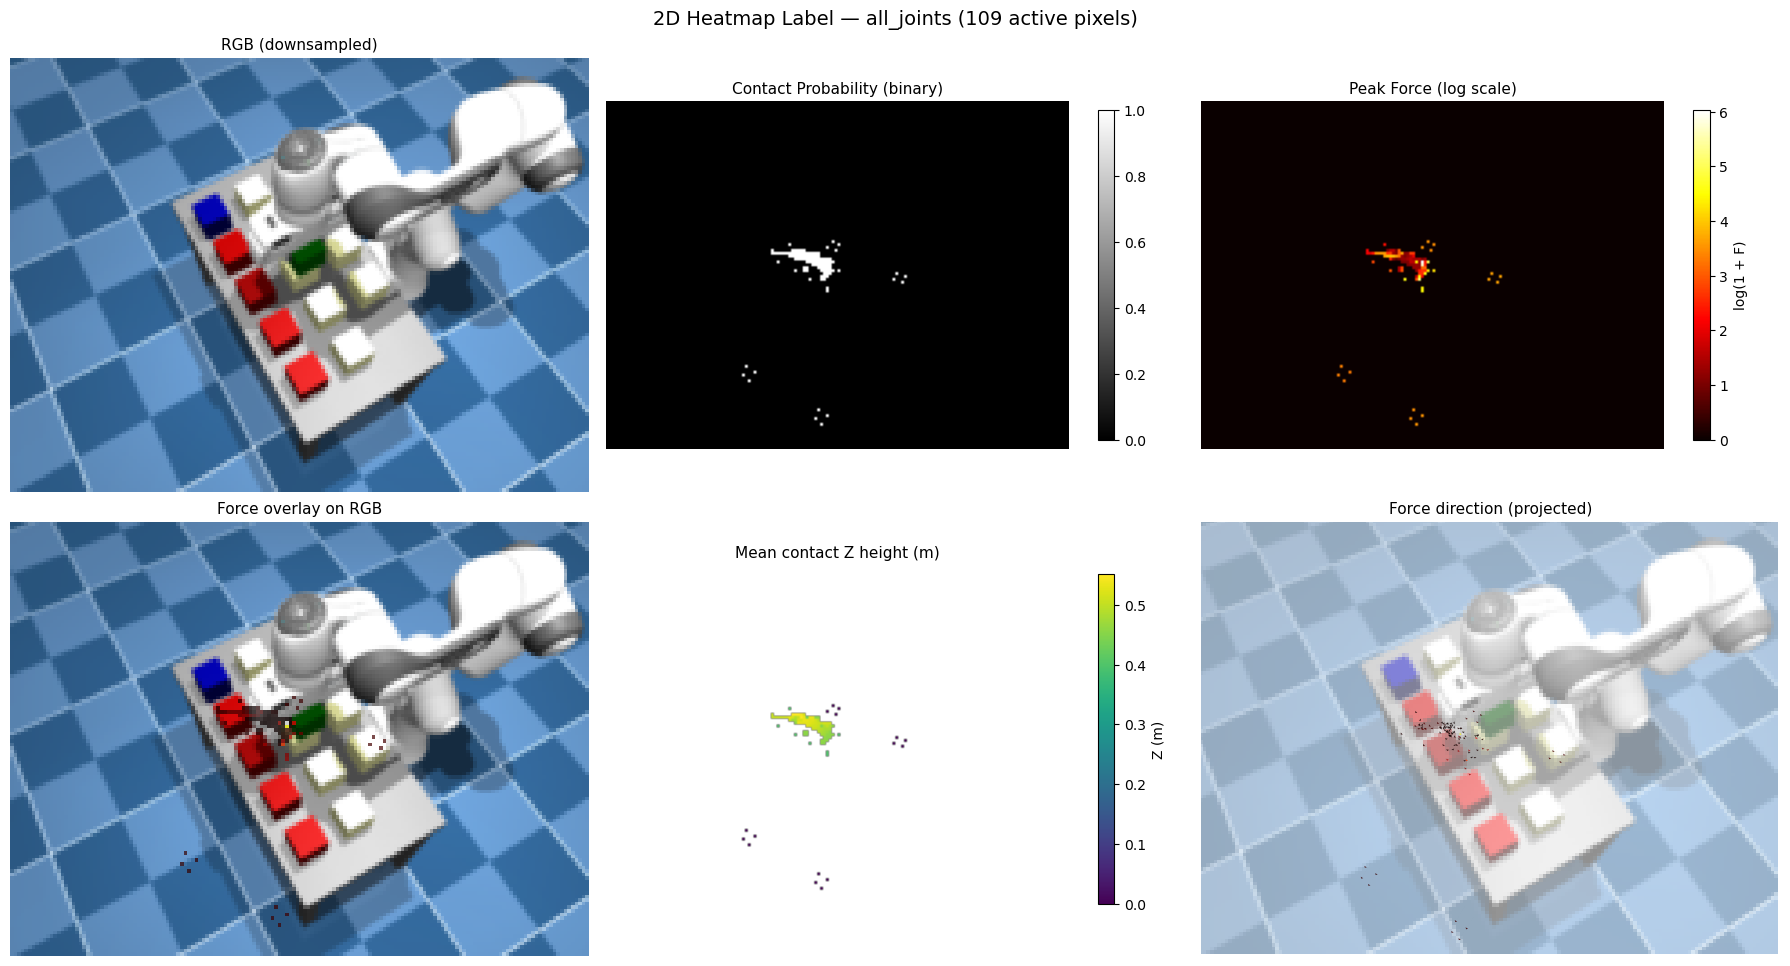

In [5]:
pre_rgb = sample["pre_rgb"]
# Downsample RGB to match heatmap
from PIL import Image
rgb_small = np.array(Image.fromarray(pre_rgb).resize((W_MAP, H_MAP), Image.BILINEAR))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: heatmap channels
axes[0, 0].imshow(rgb_small)
axes[0, 0].set_title("RGB (downsampled)", fontsize=11)
axes[0, 0].axis("off")

im1 = axes[0, 1].imshow(heatmap_prob, cmap="gray")
axes[0, 1].set_title("Contact Probability (binary)", fontsize=11)
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.7)

im2 = axes[0, 2].imshow(np.log1p(heatmap_peak_force), cmap="hot")
axes[0, 2].set_title("Peak Force (log scale)", fontsize=11)
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], shrink=0.7, label="log(1 + F)")

# Row 2: overlays on RGB
axes[1, 0].imshow(rgb_small)
force_overlay = np.zeros((*rgb_small.shape[:2], 4))
force_norm = heatmap_peak_force / max(heatmap_peak_force.max(), 1)
for v in range(H_MAP):
    for u in range(W_MAP):
        if heatmap_prob[v, u] > 0:
            c = cm.hot(force_norm[v, u])
            force_overlay[v, u] = [c[0], c[1], c[2], 0.7]
axes[1, 0].imshow(force_overlay)
axes[1, 0].set_title("Force overlay on RGB", fontsize=11)
axes[1, 0].axis("off")

# Mean Z height at contact
im3 = axes[1, 1].imshow(np.where(active, heatmap_mean_z, np.nan), cmap="viridis")
axes[1, 1].set_title("Mean contact Z height (m)", fontsize=11)
axes[1, 1].axis("off")
plt.colorbar(im3, ax=axes[1, 1], shrink=0.7, label="Z (m)")

# Force direction as quiver
axes[1, 2].imshow(rgb_small, alpha=0.5)
vs, us = np.where(active)
for v, u in zip(vs, us):
    fdir = heatmap_force_vec[v, u]
    fdir_2d = projector.project((pos_v.mean(axis=0) + fdir * 0.001)[None])[0][0] / SCALE
    origin_2d = np.array([u, v], dtype=float)
    arrow = fdir_2d - origin_2d
    arrow_len = np.linalg.norm(arrow)
    if arrow_len > 0.5:
        arrow = arrow / arrow_len * min(arrow_len, 5)
        axes[1, 2].arrow(u, v, arrow[0], arrow[1],
                         head_width=0.8, head_length=0.4,
                         fc=cm.hot(force_norm[v, u]), ec='none', alpha=0.8)
axes[1, 2].set_title("Force direction (projected)", fontsize=11)
axes[1, 2].set_xlim(0, W_MAP)
axes[1, 2].set_ylim(H_MAP, 0)
axes[1, 2].axis("off")

plt.suptitle(f"2D Heatmap Label — {failure_modes[FAILURE_ID]} ({active.sum()} active pixels)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Quantify information loss from 2D projection
from collections import defaultdict

pixel_z = defaultdict(list)
pixel_forces = defaultdict(list)
for i in range(len(px)):
    u = int(np.clip(px[i, 0] / SCALE, 0, W_MAP - 1))
    v = int(np.clip(px[i, 1] / SCALE, 0, H_MAP - 1))
    pixel_z[(v, u)].append(pos_v[i, 2])
    pixel_forces[(v, u)].append(fm[i])

z_ranges = [max(zs) - min(zs) for zs in pixel_z.values()]
z_collapse = sum(1 for r in z_ranges if r > 0.03)

print("=== 2D Heatmap Info Loss ===")
print(f"Pixels with >3cm Z collapse: {z_collapse} / {len(pixel_z)} ({100*z_collapse/len(pixel_z):.0f}%)")
print(f"Max Z range in single pixel: {max(z_ranges):.3f} m")
print(f"Contacts outside frame: {(~in_frame).sum()} / {len(positions)}")

=== 2D Heatmap Info Loss ===
Pixels with >3cm Z collapse: 19 / 109 (17%)
Max Z range in single pixel: 0.149 m
Contacts outside frame: 0 / 16495


## 2. Sparse Point Set

Aggregate contacts at 1cm resolution: each point is (x, y, z, fx, fy, fz, peak\_force).

In [7]:
# Voxelize at 1cm and aggregate
RES = 0.01

voxel_data = {}  # (xi, yi, zi) -> {peak_force, force_sum, count, positions}
for i in range(len(positions)):
    xi = int(np.round(positions[i, 0] / RES))
    yi = int(np.round(positions[i, 1] / RES))
    zi = int(np.round(positions[i, 2] / RES))
    key = (xi, yi, zi)
    if key not in voxel_data:
        voxel_data[key] = {
            "peak_force": 0.0,
            "force_vec_sum": np.zeros(3),
            "pos_sum": np.zeros(3),
            "count": 0,
        }
    v = voxel_data[key]
    v["peak_force"] = max(v["peak_force"], force_mag[i])
    v["force_vec_sum"] += forces[i, :3]
    v["pos_sum"] += positions[i]
    v["count"] += 1

# Build point set: (N, 7) = [x, y, z, fx, fy, fz, peak_force]
points = []
for key, v in voxel_data.items():
    pos_mean = v["pos_sum"] / v["count"]
    # Mean force direction, scaled by peak magnitude
    fvec = v["force_vec_sum"] / v["count"]
    points.append([
        pos_mean[0], pos_mean[1], pos_mean[2],
        fvec[0], fvec[1], fvec[2],
        v["peak_force"],
    ])

point_set = np.array(points, dtype=np.float32)
print(f"Sparse point set: {len(point_set)} points (from {len(positions):,} raw contacts)")
print(f"Output size: {point_set.shape} = {point_set.size} floats")
print(f"\nPosition range:")
print(f"  X: [{point_set[:,0].min():.3f}, {point_set[:,0].max():.3f}]")
print(f"  Y: [{point_set[:,1].min():.3f}, {point_set[:,1].max():.3f}]")
print(f"  Z: [{point_set[:,2].min():.3f}, {point_set[:,2].max():.3f}]")
print(f"Peak force range: [{point_set[:,6].min():.1f}, {point_set[:,6].max():.1f}] N")

Sparse point set: 182 points (from 16,495 raw contacts)
Output size: (182, 7) = 1274 floats

Position range:
  X: [-0.295, 0.295]
  Y: [-0.505, -0.195]
  Z: [-0.000, 0.556]
Peak force range: [1.0, 414.7] N


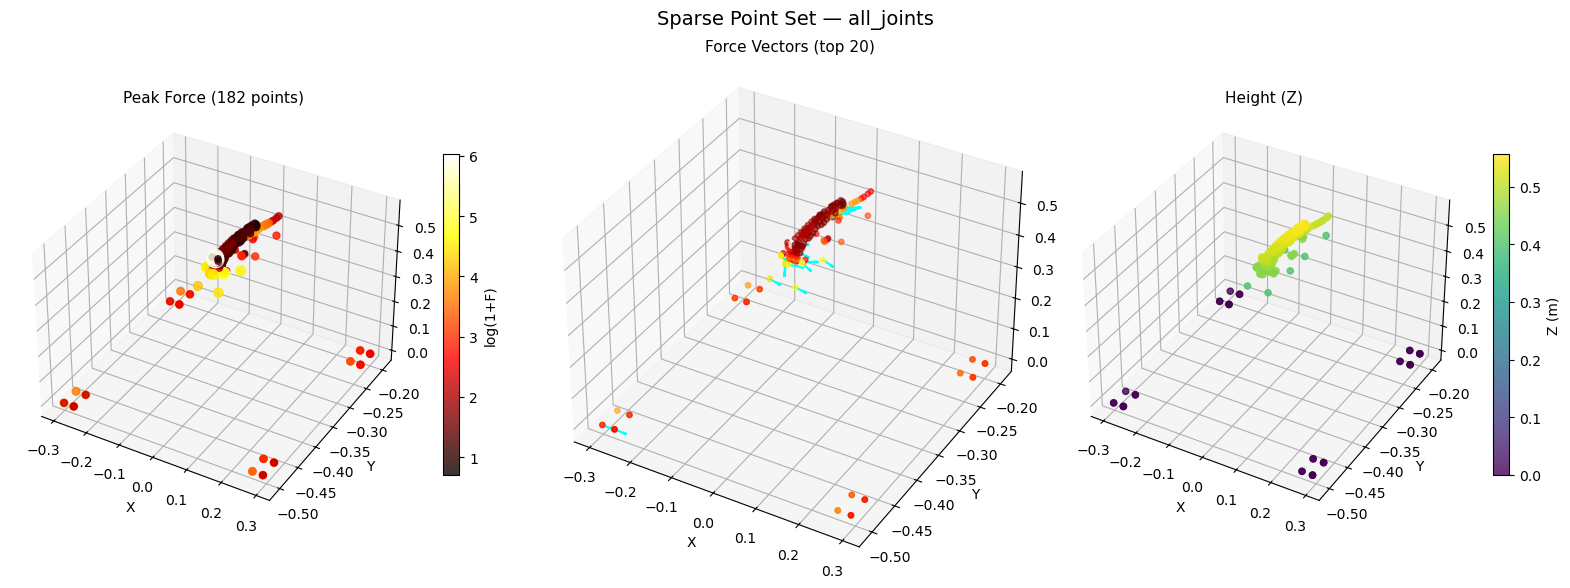

In [8]:
# 3D visualization of the sparse point set
fig = plt.figure(figsize=(16, 6))

# View 1: colored by peak force
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(point_set[:, 0], point_set[:, 1], point_set[:, 2],
                 c=np.log1p(point_set[:, 6]), cmap='hot',
                 s=20 + point_set[:, 6] * 0.3, alpha=0.8)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title(f'Peak Force ({len(point_set)} points)', fontsize=11)
plt.colorbar(sc, ax=ax1, shrink=0.6, label='log(1+F)')

# View 2: with force direction arrows
ax2 = fig.add_subplot(132, projection='3d')
f_norm = np.log1p(point_set[:, 6])
f_colors = cm.hot(f_norm / max(f_norm.max(), 1))
ax2.scatter(point_set[:, 0], point_set[:, 1], point_set[:, 2],
            c=f_colors, s=15, alpha=0.6)
# Draw force arrows for top-20 force points
top_idx = np.argsort(-point_set[:, 6])[:20]
for i in top_idx:
    p = point_set[i, :3]
    f = point_set[i, 3:6]
    f_dir = f / (np.linalg.norm(f) + 1e-8) * 0.03  # 3cm arrow
    ax2.quiver(p[0], p[1], p[2], f_dir[0], f_dir[1], f_dir[2],
              color='cyan', arrow_length_ratio=0.3, linewidth=1.5)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('Force Vectors (top 20)', fontsize=11)

# View 3: colored by Z height
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(point_set[:, 0], point_set[:, 1], point_set[:, 2],
                  c=point_set[:, 2], cmap='viridis', s=20, alpha=0.8)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.set_title('Height (Z)', fontsize=11)
plt.colorbar(sc3, ax=ax3, shrink=0.6, label='Z (m)')

for ax in [ax1, ax2, ax3]:
    ax.view_init(elev=35, azim=-60)

plt.suptitle(f'Sparse Point Set — {failure_modes[FAILURE_ID]}', fontsize=14)
plt.tight_layout()
plt.show()

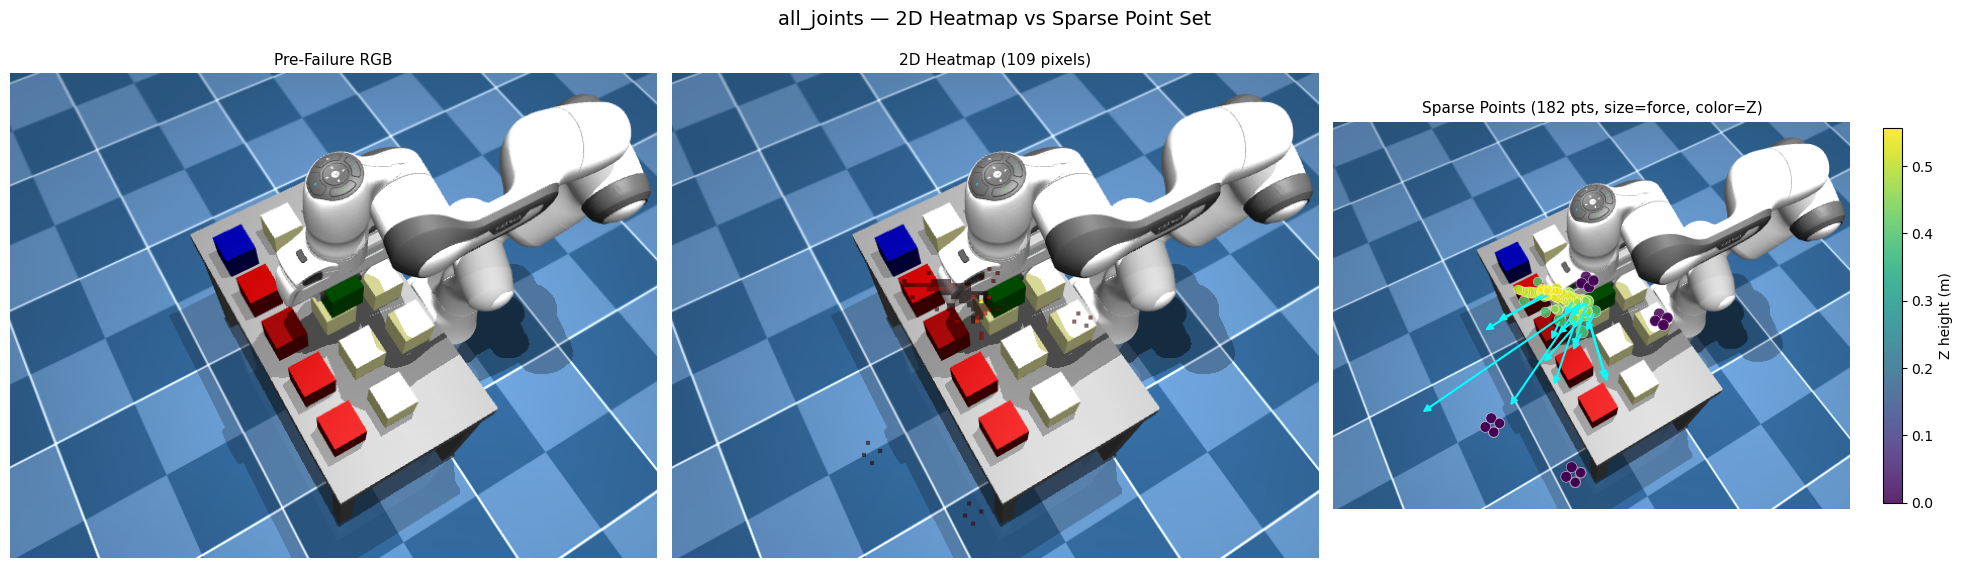

In [9]:
# Project the sparse point set back onto the RGB image for comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: raw RGB
axes[0].imshow(pre_rgb)
axes[0].set_title('Pre-Failure RGB', fontsize=11)
axes[0].axis('off')

# Middle: 2D heatmap overlay (for comparison)
axes[1].imshow(pre_rgb)
hm_full = np.zeros((480, 640, 4))
for v in range(H_MAP):
    for u in range(W_MAP):
        if heatmap_prob[v, u] > 0:
            c = cm.hot(force_norm[v, u])
            hm_full[v*SCALE:(v+1)*SCALE, u*SCALE:(u+1)*SCALE] = [c[0], c[1], c[2], 0.6]
axes[1].imshow(hm_full)
axes[1].set_title(f'2D Heatmap ({active.sum()} pixels)', fontsize=11)
axes[1].axis('off')

# Right: sparse point set projected
axes[2].imshow(pre_rgb)
pt_pixels, pt_depths = projector.project(point_set[:, :3])
pt_in = projector.in_frame(pt_pixels, pt_depths)
pt_px = pt_pixels[pt_in]
pt_f = point_set[pt_in, 6]
pt_z = point_set[pt_in, 2]

# Size by force, color by Z height
f_norm_pt = np.log1p(pt_f)
sc = axes[2].scatter(pt_px[:, 0], pt_px[:, 1],
                     c=pt_z, cmap='viridis',
                     s=10 + f_norm_pt * 15,
                     edgecolors='white', linewidths=0.3, alpha=0.85, zorder=2)
plt.colorbar(sc, ax=axes[2], shrink=0.7, label='Z height (m)')

# Force arrows for top points
top_idx_vis = np.argsort(-pt_f)[:15]
for idx in top_idx_vis:
    i_global = np.where(pt_in)[0][idx]
    p3d = point_set[i_global, :3]
    fvec = point_set[i_global, 3:6]
    tip_3d = p3d + fvec * 0.003
    tip_px, _ = projector.project(tip_3d[None])
    origin = pt_px[idx]
    arrow = tip_px[0] - origin
    if np.linalg.norm(arrow) > 1:
        axes[2].annotate('', xy=tip_px[0], xytext=origin,
                        arrowprops=dict(arrowstyle='-|>', color='cyan', lw=1.5))

axes[2].set_title(f'Sparse Points ({pt_in.sum()} pts, size=force, color=Z)', fontsize=11)
axes[2].set_xlim(0, 640)
axes[2].set_ylim(480, 0)
axes[2].axis('off')

plt.suptitle(f'{failure_modes[FAILURE_ID]} — 2D Heatmap vs Sparse Point Set', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Side-by-Side Comparison Across Failure Modes

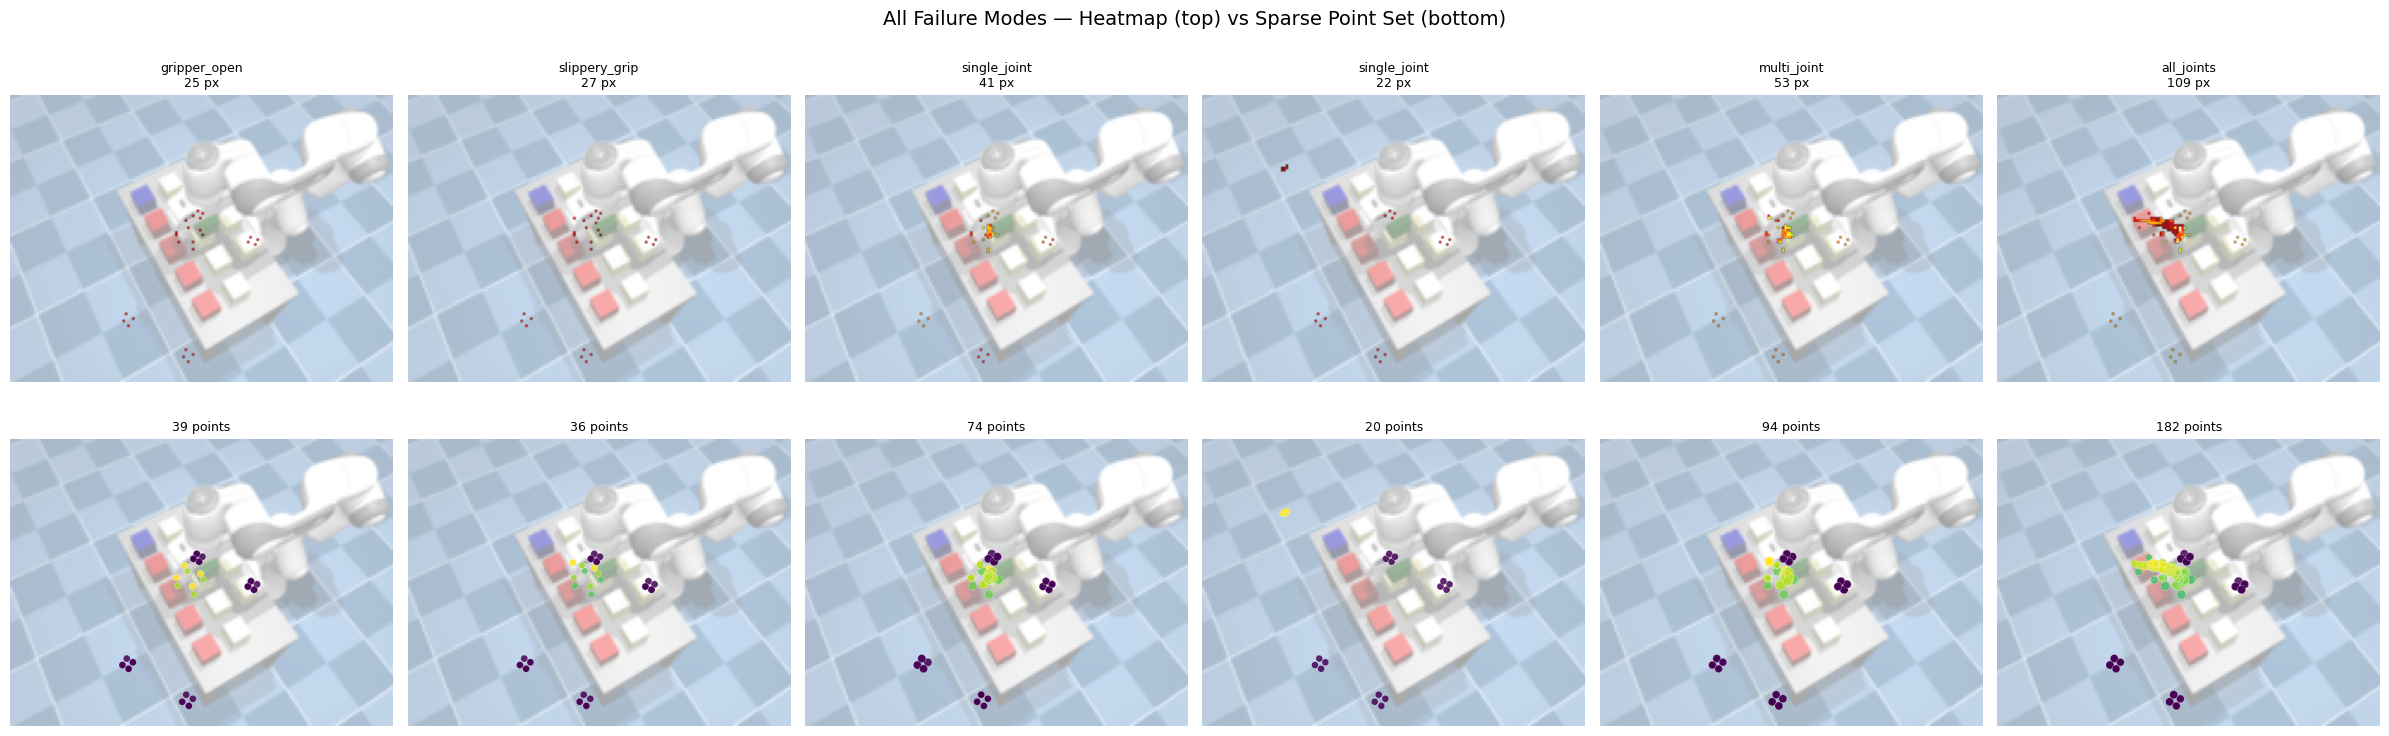

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for fid in range(len(failure_modes)):
    mask_f = sample["contact_failure_id"] == fid
    pos_f = sample["contact_positions"][mask_f]
    forces_f = sample["contact_forces"][mask_f]
    fmag_f = np.linalg.norm(forces_f[:, :3], axis=1)

    # --- Row 0: 2D heatmap ---
    px_f, dp_f = projector.project(pos_f)
    inf_f = projector.in_frame(px_f, dp_f)
    hm = np.zeros((H_MAP, W_MAP), dtype=np.float32)
    for i in np.where(inf_f)[0]:
        u = int(np.clip(px_f[i, 0] / SCALE, 0, W_MAP - 1))
        v = int(np.clip(px_f[i, 1] / SCALE, 0, H_MAP - 1))
        hm[v, u] = max(hm[v, u], fmag_f[i])

    axes[0, fid].imshow(rgb_small, alpha=0.4)
    hm_vis = np.ma.masked_where(hm == 0, np.log1p(hm))
    axes[0, fid].imshow(hm_vis, cmap='hot', alpha=0.9,
                        vmin=0, vmax=np.log1p(400))
    n_px = (hm > 0).sum()
    axes[0, fid].set_title(f'{failure_modes[fid]}\n{n_px} px', fontsize=9)
    axes[0, fid].axis('off')

    # --- Row 1: sparse point set ---
    vd = {}
    for i in range(len(pos_f)):
        key = tuple(np.round(pos_f[i] / RES).astype(int))
        if key not in vd:
            vd[key] = {'pos': np.zeros(3), 'peak': 0.0, 'n': 0}
        vd[key]['pos'] += pos_f[i]
        vd[key]['peak'] = max(vd[key]['peak'], fmag_f[i])
        vd[key]['n'] += 1

    if vd:
        pts = np.array([[*(v['pos']/v['n']), v['peak']] for v in vd.values()])
        pts_px, pts_dp = projector.project(pts[:, :3])
        pts_in = projector.in_frame(pts_px, pts_dp)

        axes[1, fid].imshow(rgb_small, extent=[0, 640, 480, 0], alpha=0.4)
        if pts_in.any():
            pf = pts[pts_in, 3]
            pz = pts[pts_in, 2]
            axes[1, fid].scatter(pts_px[pts_in, 0], pts_px[pts_in, 1],
                                c=pz, cmap='viridis',
                                s=8 + np.log1p(pf) * 8,
                                edgecolors='white', linewidths=0.2, alpha=0.85)
        axes[1, fid].set_title(f'{len(pts)} points', fontsize=9)
    else:
        axes[1, fid].set_title('0 points', fontsize=9)
    axes[1, fid].set_xlim(0, 640)
    axes[1, fid].set_ylim(480, 0)
    axes[1, fid].axis('off')

axes[0, 0].set_ylabel('2D Heatmap', fontsize=12, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('Sparse Points', fontsize=12, rotation=90, labelpad=10)
plt.suptitle('All Failure Modes — Heatmap (top) vs Sparse Point Set (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Output Size Comparison

In [11]:
print(f"{'Representation':<30s} {'Shape':<20s} {'Total floats':<15s} {'Notes'}")
print("-" * 85)
print(f"{'Raw contacts':<30s} {str((len(positions), 7)):<20s} {len(positions)*7:<15,d} {'variable size, redundant'}")
print(f"{'2D heatmap (120x160x2)':<30s} {'(120, 160, 2)':<20s} {120*160*2:<15,d} {'prob + peak force'}")
print(f"{'2D heatmap (120x160x5)':<30s} {'(120, 160, 5)':<20s} {120*160*5:<15,d} {'+ force direction'}")
print(f"{'Sparse point set @1cm':<30s} {str(point_set.shape):<20s} {point_set.size:<15,d} {'xyz + force vec + peak'}")
print(f"{'Padded point set (256x7)':<30s} {'(256, 7)':<20s} {256*7:<15,d} {'fixed size with mask'}")
print()
print(f"Heatmap sparsity: {100*(1 - active.sum()/(H_MAP*W_MAP)):.1f}% empty")
print(f"Point set: {len(point_set)} points = {point_set.size} values (compact by construction)")

Representation                 Shape                Total floats    Notes
-------------------------------------------------------------------------------------
Raw contacts                   (16495, 7)           115,465         variable size, redundant
2D heatmap (120x160x2)         (120, 160, 2)        38,400          prob + peak force
2D heatmap (120x160x5)         (120, 160, 5)        96,000          + force direction
Sparse point set @1cm          (182, 7)             1,274           xyz + force vec + peak
Padded point set (256x7)       (256, 7)             1,792           fixed size with mask

Heatmap sparsity: 99.4% empty
Point set: 182 points = 1274 values (compact by construction)
